In [1]:
import wids
from PIL import ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

TOTAL_NUM = 10016544
YFCC_URL = "https://storage.cmusatyalab.org/yfcc100m/yfcc100m.json"
OUTPUT_PATH = "/home/ubuntu/yfcc-scope/clip-embedding/yfcc_image_embeddings.npy"

ds = wids.ShardListDataset(YFCC_URL)

https://storage.cmusatyalab.org/yfcc100m/yfcc100m. base: https://storage.cmusatyalab.org/yfcc100m name: yfcc100m nfiles: 403 nbytes: 1264357191680 samples: 10016544 cache: /tmp/_wids_cache
/home/ubuntu/yfcc-scope/.venv/lib/python3.10/site-packages/wids/wids.py:316: UserWarning: String specifications for transformations are deprecated. Use functions instead.
  warnings.warn("String specifications for transformations are deprecated. Use functions instead.")


### Test with the first image

In [2]:
ds[0]

{'.jpg': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=500x375>,
 '.json': {'image_id': 10201275523,
  'user_uid': '55289779@N00',
  'flickr_url': 'http://www.flickr.com/photos/55289779@N00/10201275523/',
  'username': 'booledozer',
  'image_crc': '3e6ea67c7f',
  'upload_time': '2013-10-11T04:10:28Z',
  'license_id': 'CC-BY-SA-2.0',
  'capture_time': '2013-10-09T15:30:13',
  'camera_model': 'Panasonic DMC-ZS10',
  'caption': 'Images from the intersection of Parliament and Queen, 2013 10 09 (3)',
  'description': None,
  'tags': [],
  'machine_tags': [],
  'gps_coord': [43.649708, -79.365637]},
 '.txt': '# Images from the intersection of Parliament and Queen, 2013 10 09 (3)',
 '__key__': '10201275523',
 '__dataset__': None,
 '__index__': 0,
 '__shard__': 'https://storage.cmusatyalab.org/yfcc100m/yfcc100m-000000.tar',
 '__shardindex__': 0}

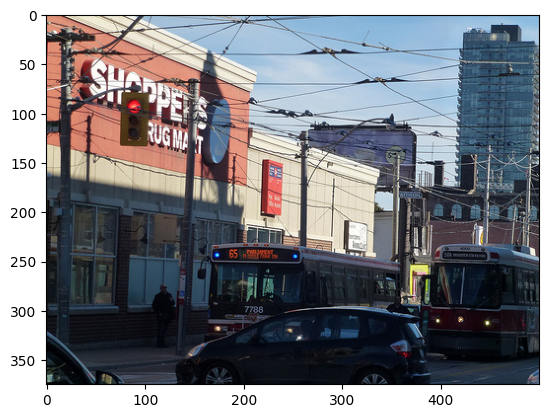

In [3]:
import matplotlib.pyplot as plt

plt.imshow(ds[0][".jpg"])

In [4]:
import torch
import open_clip

model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
model.eval()  # model in train mode by default, impacts some models with BatchNorm or stochastic depth active
tokenizer = open_clip.get_tokenizer('ViT-B-32')

# Test on the first image
image = preprocess(ds[0][".jpg"]).unsqueeze(0)
text = tokenizer(["cars", "a cat", "a dog"])

device = "cuda" if torch.cuda.is_available() else "cpu"
with torch.no_grad(), torch.autocast(device):
    image_features = model.encode_image(image)
    text_features = model.encode_text(text)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)

print("Label probs:", text_probs)

Label probs: tensor([[0.8192, 0.0050, 0.1758]])


In [5]:
image_features.dtype, image_features.shape

(torch.float32, torch.Size([1, 512]))

### Compute CLIP embedding for all webdataset images

#### Naive for loop (not used)

In [ ]:
import numpy as np
from tqdm import tqdm

# Naive for loop: compute embedding per image and save to disk
output_path = "/home/ubuntu/yfcc-scope/clip-embedding/yfcc_image_embeddings.npy"
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

# Determine embedding dimension from the first image
sample = preprocess(ds[0][".jpg"]).unsqueeze(0).to(device)
with torch.no_grad(), torch.autocast(device):
    emb_dim = model.encode_image(sample).shape[-1]

# Create a disk-backed array so we don't keep everything in RAM
embeddings = np.lib.format.open_memmap(
    output_path, mode="w+", dtype=np.float16, shape=(TOTAL_NUM, emb_dim)
 )

use_amp = device == "cuda"

for i in tqdm(range(TOTAL_NUM)):
    image = preprocess(ds[i][".jpg"]).unsqueeze(0).to(device)
    with torch.no_grad():
        if use_amp:
            with torch.autocast(device):
                feat = model.encode_image(image)
        else:
            feat = model.encode_image(image)

        feat = feat / feat.norm(dim=-1, keepdim=True)

    embeddings[i] = feat.cpu().numpy().astype(np.float16, copy=False)

# Ensure data is flushed to disk
embeddings.flush()

#### Batched for loop using DataLoader

See [yfcc_img_to_clip.py](./yfcc_img_to_clip.py)

### Check the CLIP embeddings written to disk

Embeddings checked:
- First embedding
- Last embedding
- Last embedding of the first shard
- First embedding of the second shard
- First embedding of the last shard
- Last embedding of the second last shard

In [6]:
import numpy as np

emb = np.load("/home/ubuntu/yfcc-scope/clip-embedding/yfcc_image_embeddings.npy")
print(emb.shape, emb.dtype)

print(emb[0])

(10016544, 512) float16
[ 4.2572e-02  1.0933e-02 -6.1615e-02  2.6978e-02 -4.2572e-02  3.3081e-02
  5.4016e-02 -2.0218e-02  4.5502e-02 -9.6802e-02  1.9150e-03 -1.3321e-02
  1.9958e-02 -8.4656e-02  1.4954e-02 -7.7772e-04 -5.5206e-02 -3.5057e-03
  3.1219e-02 -5.1666e-02 -3.6041e-02 -6.8115e-02 -1.9821e-02  4.0527e-02
 -4.7569e-03 -5.3589e-02  4.8904e-03  1.7853e-02 -7.3914e-02  4.3701e-02
 -2.2171e-02  3.4885e-03  1.6052e-02  4.0161e-02  4.0619e-02  4.3297e-03
 -1.7410e-02  6.1264e-03  1.1063e-02  1.9348e-02 -1.4629e-03  6.5842e-03
  5.9570e-02  3.8338e-03  9.8648e-03 -3.5675e-02  4.0802e-02 -4.7699e-02
  3.2440e-02 -6.4270e-02 -4.0619e-02 -2.1637e-02 -3.8452e-02  6.6261e-03
 -9.1919e-02  7.3669e-02 -3.9398e-02  2.2629e-02 -4.4189e-02  8.7830e-02
 -1.2903e-01  3.2593e-02 -5.3528e-02 -1.1452e-02  3.4698e-02 -1.7151e-02
 -3.5675e-02 -9.4177e-02  4.3335e-02  3.3936e-02 -5.7770e-02 -5.4199e-02
 -1.3809e-02  2.2186e-02  1.9928e-02  4.1718e-02  1.0608e-01 -2.1027e-02
  3.5114e-03 -3.1525e-02  5

In [7]:
# Compute similarity between the embedding saved in disk and the CLIP embedding computed on the fly for the same image

import numpy as np
import torch

def diff_norm(a, b):
    return float(np.linalg.norm(a - b))

def cos_sim(a, b):
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    return float(np.dot(a, b) / denom)

def compare(emb, img):
    dn = diff_norm(emb, img)
    cs = cos_sim(emb, img)
    return dn, cs

def compute_image_feature(idx, ds, preprocess, model, device=None):
    image = preprocess(ds[idx][".jpg"]).unsqueeze(0)
    with torch.no_grad(), torch.autocast(device):
        feat = model.encode_image(image)
        feat = feat / feat.norm(dim=-1, keepdim=True)
    return feat

def to_numpy(feat):
    return feat[0].detach().cpu().float().numpy()

def get_shard_lengths(ds):
    shardlist = ds.shards
    return [s['nsamples'] for s in shardlist]

lengths = get_shard_lengths(ds)
starts = np.cumsum([0] + lengths[:-1])
ends = starts + np.array(lengths) - 1

assert emb.shape[0] == TOTAL_NUM, f"Expected {TOTAL_NUM} embeddings, but got {emb.shape[0]}"

checks = [
    ("first_embedding", 0),
    ("last_embedding", int(emb.shape[0] - 1)),
    ("first_shard_last", int(ends[0])),
	("second_shard_first", int(starts[1])),
	("second_last_shard_last", int(ends[-2])),
    ("last_shard_first", int(starts[-1])),
]

img_feats = []

for label, idx in checks:
    img_feats.append(compute_image_feature(idx, ds, preprocess, model, device=device))
    dn, cs = compare(emb[idx].astype(np.float32, copy=False), to_numpy(img_feats[-1]))
    print(f"{label}: idx={idx}, diff_norm={dn}, cos_sim={cs}")

first_embedding: idx=0, diff_norm=0.0026453062891960144, cos_sim=0.9999965429976005
last_embedding: idx=10016543, diff_norm=0.004128419794142246, cos_sim=0.9999915366186758
first_shard_last: idx=24790, diff_norm=0.0024347903672605753, cos_sim=0.9999971391233813
second_shard_first: idx=24791, diff_norm=0.002290082164108753, cos_sim=0.9999973773729013
second_last_shard_last: idx=9991613, diff_norm=0.002875465899705887, cos_sim=0.9999958278325238
last_shard_first: idx=9991614, diff_norm=0.0024915782269090414, cos_sim=0.9999969601583115


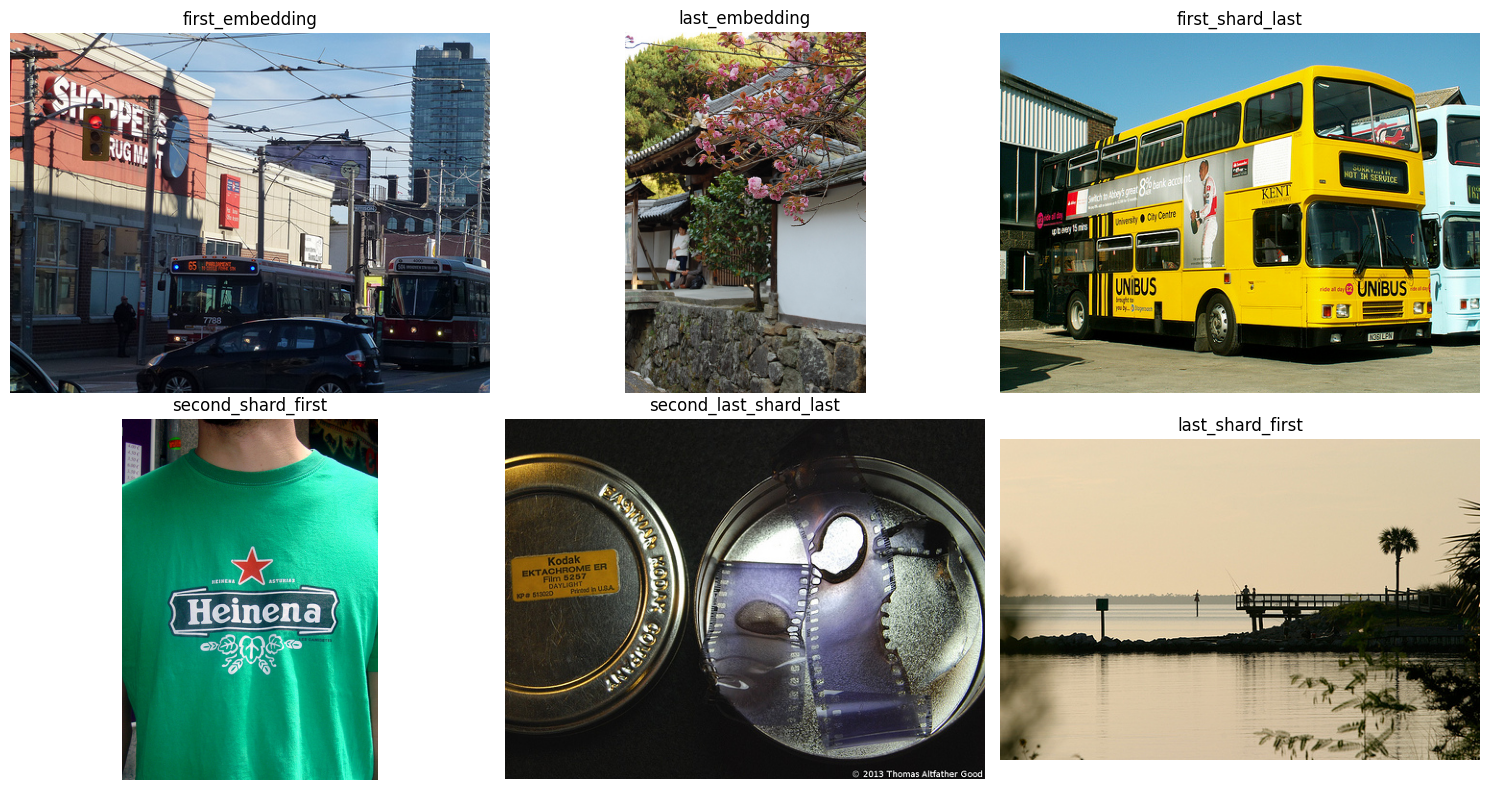

In [8]:
# Show the checked images

import math
import matplotlib.pyplot as plt

num = len(checks)
cols = 3
rows = math.ceil(num / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

for i, (label, idx) in enumerate(checks):
    axes[i].imshow(ds[idx][".jpg"])
    axes[i].set_title(label)
    axes[i].axis("off")

for j in range(num, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Check the similarity with text embeddings

check_texts = ["street", "flowers", "a bus", "green shirt", "a can", "lake"]

def compute_text_features(texts, model, tokenizer, device=None):
    text_input = tokenizer(texts)
    with torch.no_grad(), torch.autocast(device):
        text_feat = model.encode_text(text_input)
        text_feat = text_feat / text_feat.norm(dim=-1, keepdim=True)
    return text_feat


text_features = compute_text_features(check_texts, model, tokenizer, device=device)

for i, (label, idx) in enumerate(checks):
    text_probs = (100.0 * img_feats[i] @ text_features.T).softmax(dim=-1)
    print(f"{label} text similarity: {text_probs[0].cpu().numpy()}")

first_embedding text similarity: [9.7465861e-01 1.2953302e-05 2.5267486e-02 4.4996005e-07 1.2360257e-05
 4.8271464e-05]
last_embedding text similarity: [8.7088758e-01 1.2112815e-01 8.3651417e-04 1.6336289e-06 3.9132591e-04
 6.7546642e-03]
first_shard_last text similarity: [3.4214270e-05 4.7031565e-09 9.9996531e-01 2.3546850e-11 1.7263254e-08
 4.9680870e-07]
second_shard_first text similarity: [5.9218029e-04 9.9979900e-07 1.1432543e-06 9.9935585e-01 4.3518201e-05
 6.2667486e-06]
second_last_shard_last text similarity: [1.0639157e-03 1.3154164e-07 5.6225526e-06 5.0162097e-10 9.9827468e-01
 6.5553444e-04]
last_shard_first text similarity: [7.7993837e-03 8.6174754e-07 7.1908826e-06 5.0376195e-07 4.2722870e-05
 9.9214935e-01]


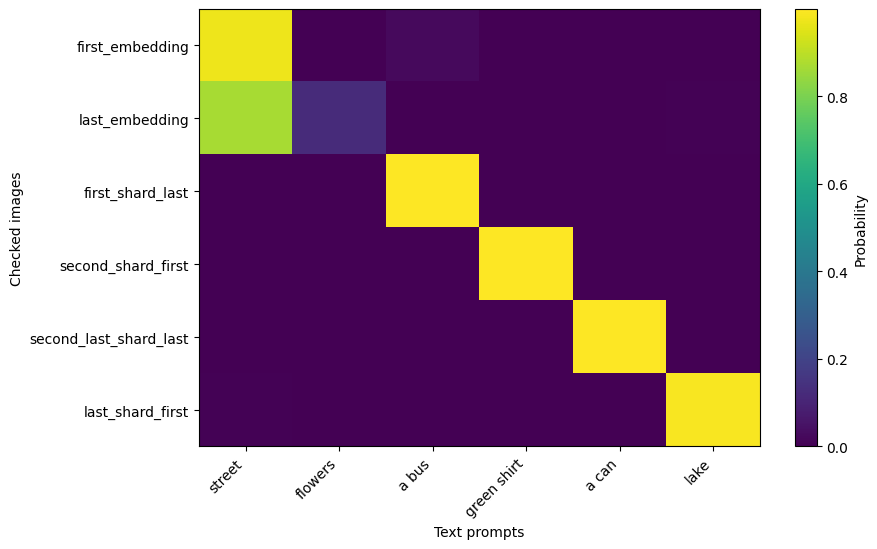

In [10]:
# Plot a similarity heatmap (images x texts)

import numpy as np
import matplotlib.pyplot as plt

heat_rows = []
for i, _ in enumerate(checks):
    probs = (100.0 * img_feats[i] @ text_features.T).softmax(dim=-1)
    heat_rows.append(probs[0].detach().cpu().numpy())

heatmap = np.vstack(heat_rows)

fig, ax = plt.subplots(figsize=(1.2 * len(check_texts) + 2, 0.6 * len(checks) + 2))
im = ax.imshow(heatmap, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(check_texts)))
ax.set_xticklabels(check_texts, rotation=45, ha="right")
ax.set_yticks(range(len(checks)))
ax.set_yticklabels([label for label, _ in checks])
ax.set_xlabel("Text prompts")
ax.set_ylabel("Checked images")
fig.colorbar(im, ax=ax, label="Probability")
plt.tight_layout()
plt.show()

### Check the CLIP embeddings written to Postgres

In [11]:
def get_image_id(idx, ds):
	img_json = ds[idx]['.json']
	return f"{img_json['image_id']}_{img_json['image_crc']}"

import os
import psycopg2

def open_conn():
    return psycopg2.connect(
        dbname=os.environ.get("DB_NAME", "yfcc"),
        user=os.environ.get("DB_USER", "postgres"),
        password=os.environ.get("DB_PASSWORD", "postgres"),
        host=os.environ.get("DB_HOST", "127.0.0.1"),
        port=int(os.environ.get("DB_PORT", 5432)),
    )

from pgvector.psycopg2 import register_vector

with open_conn() as conn:
	register_vector(conn)
	with conn.cursor() as cur:

		for check_idx, (label, idx) in enumerate(checks):
			img_id = get_image_id(idx, ds)

			# Query clip_embedding from database
			cur.execute("SELECT embedding FROM clip_embeddings WHERE image_file_id = %s", (img_id,))
			result = cur.fetchone()

			if result is None:
				print(f"{label}: idx={idx}, image_id={img_id} - NOT FOUND in database")
				continue

			db_embedding = result[0].to_numpy()
			computed_embedding = to_numpy(img_feats[check_idx])

			# Compare embeddings from database and computed on the fly
			dn, cs = compare(db_embedding, computed_embedding)
			print(f"{label}: idx={idx}, image_id={img_id}, diff_norm={dn}, cos_sim={cs}")

first_embedding: idx=0, image_id=10201275523_3e6ea67c7f, diff_norm=0.0026453062891960144, cos_sim=1.0000162124623788
last_embedding: idx=10016543, image_id=3454520277_0aacab8dc8, diff_norm=0.004128419794142246, cos_sim=1.0000483989820967
first_shard_last: idx=24790, image_id=10088202244_244981b316, diff_norm=0.0024347903672605753, cos_sim=1.0000486373891366
second_shard_first: idx=24791, image_id=3614644828_19dc6cb62a, diff_norm=0.002290082164108753, cos_sim=0.999989271161022
second_last_shard_last: idx=9991613, image_id=10454951454_341e44e721, diff_norm=0.002875465899705887, cos_sim=1.000033736223921
last_shard_first: idx=9991614, image_id=7729303084_534e30bb07, diff_norm=0.0024915782269090414, cos_sim=0.9999957084645761
